# Проверка пересечения сплошной линии в MetaDrive

Демонстрация работы модуля для обнаружения пересечений автомобилем сплошных линий разметки:
- Сохранение траектории проезда
- Проверка пересечений сплошных линий
- Визуализация траектории в виде GIF


In [1]:
# Импорт необходимых библиотек
# Автоматическая перезагрузка модулей при изменении (autoreload)
%load_ext autoreload
%autoreload 2

import os
import sys
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Настройка путей
BASE_DIR = '/home/jovyan/shares/SR006.nfs1/arbelyaev'
sys.path.insert(0, BASE_DIR)
sys.path.insert(0, f'{BASE_DIR}/sdc')
sys.path.insert(0, f'{BASE_DIR}/metadrive')

# Импорт MetaDrive
from metadrive.envs.top_down_env import TopDownMetaDrive
from metadrive.manager.traffic_manager import TrafficMode
from metadrive.constants import DEFAULT_AGENT

# Импорт нашего модуля
from metadrive_custom.solid_line_detector import SolidLineDetector

print("✅ Все модули успешно импортированы!")


✅ Все модули успешно импортированы!


## Настройка и запуск симуляции


In [2]:
# Создание детектора пересечений и окружения
detector = SolidLineDetector(trajectory_history_size=2000)

# Создание окружения MetaDrive
# Важно: отключаем автоматическое завершение при выходе за пределы дороги,
# чтобы траектория продолжалась даже после пересечения желтой линии
config = dict(
    num_scenarios=1,
    start_seed=1000,
    log_level=50,
    use_render=False,
    horizon=2000,
    random_lane_width=True,
    random_lane_num=True,
    traffic_density=0.1,
    traffic_mode=TrafficMode.Trigger,
    # КЛЮЧЕВОЙ ПАРАМЕТР: отключаем завершение эпизода при выходе за пределы дороги
    out_of_road_done=False,  # Эпизод НЕ будет завершаться при пересечении желтой линии
    out_of_route_done=False,  # Не завершать при выходе с маршрута
    # Также отключаем завершение при пересечении сплошной линии (если нужно)
    on_continuous_line_done=False,  # Не завершать при пересечении сплошной линии
    # Убираем штрафы для чистоты демонстрации
    out_of_road_penalty=0.0,
    crash_vehicle_penalty=0.0,
    crash_object_penalty=0.0,
)

env = TopDownMetaDrive(config)
obs, info = env.reset()

# Получаем базовое окружение для доступа к автомобилю и карте
base_env = env.unwrapped
while hasattr(base_env, 'env'):
    base_env = base_env.env

# Получаем автомобиль
vehicle = base_env.vehicle if hasattr(base_env, 'vehicle') else None
if vehicle is None and hasattr(base_env, 'agents'):
    vehicle = base_env.agents.get(DEFAULT_AGENT, None)

# Включаем запись для GIF
if hasattr(base_env, "top_down_renderer") and base_env.top_down_renderer is not None:
    base_env.top_down_renderer.screen_record = True
    base_env.top_down_renderer._screen_frames = []

print("✅ Окружение и детектор готовы!")


✅ Окружение и детектор готовы!


## Запуск симуляции: сохранение траектории и проверка пересечений


In [3]:
# Функция для получения текущей полосы
def get_current_lane(vehicle):
    """Получить текущую полосу, на которой находится автомобиль"""
    if vehicle is None:
        return None
    try:
        if hasattr(vehicle, 'navigation') and vehicle.navigation is not None:
            if hasattr(vehicle.navigation, 'current_lane') and vehicle.navigation.current_lane is not None:
                return vehicle.navigation.current_lane
            if hasattr(vehicle.navigation, 'current_ref_lanes') and vehicle.navigation.current_ref_lanes:
                return vehicle.navigation.current_ref_lanes[0]
        if 'base_env' in globals() and hasattr(base_env, 'current_map') and base_env.current_map is not None:
            road_network = base_env.current_map.road_network
            if hasattr(road_network, 'get_closest_lane'):
                try:
                    return road_network.get_closest_lane(vehicle.position)
                except:
                    pass
    except:
        pass
    return None

# Политика управления, которая заставляет пересекать сплошные линии
def crossing_policy(vehicle, obs, step):
    """Политика управления, которая намеренно пересекает сплошные линии"""
    if vehicle is None:
        return [0.0, 0.0]
    
    # Базовое ускорение
    acceleration = 0.6
    
    # Стратегия пересечения линии:
    # 1. Первые 50 шагов - едем прямо
    # 2. С 50 по 150 шагов - резкий поворот влево для пересечения левой линии
    # 3. С 150 по 250 шагов - поворот вправо для возврата и пересечения правой линии
    # 4. После 250 - продолжаем с небольшими поворотами
    
    steering = 0.0
    
    if 50 <= step < 150:
        # Резкий поворот влево для пересечения левой сплошной линии
        steering = 0.5 + np.sin(step * 0.1) * 0.3
    elif 150 <= step < 250:
        # Поворот вправо для пересечения правой сплошной линии
        steering = -0.5 - np.sin(step * 0.1) * 0.3
    elif step >= 250:
        # Продолжаем с небольшими поворотами для возможных дополнительных пересечений
        steering = np.sin(step * 0.05) * 0.4
    
    return [steering, acceleration]


In [4]:
# Запуск симуляции: сохранение траектории и проверка пересечений
max_steps = 500
all_intersections = []

print(f"🚗 Запуск симуляции на {max_steps} шагов...")
print("=" * 60)
print("⚠️  Используется политика, которая намеренно пересекает сплошные линии")
print("=" * 60)

# Первый рендер
env.render(mode="top_down", screen_record=True, window=False, screen_size=(600, 600))

for step in range(max_steps):
    if vehicle is None:
        break
    
    # Получаем текущую позицию и полосу
    position = vehicle.position
    current_lane = get_current_lane(vehicle)
    
    # Сохранение траектории проезда
    detector.add_position(position, current_lane)
    
    # Проверка пересечения линии (достаточно хотя бы одного пересечения)
    if step % 10 == 0:
        intersections = detector.detect_crossings(
            current_map=base_env.current_map if hasattr(base_env, 'current_map') else None
        )
        
        # Добавляем все новые пересечения
        if intersections:
            for intersection in intersections:
                # Проверяем, не было ли уже такого пересечения (по позиции и стороне)
                is_duplicate = False
                for existing in all_intersections:
                    pos_diff = np.linalg.norm(existing['position'] - intersection['position'])
                    if pos_diff < 2.0 and existing['side'] == intersection['side']:
                        is_duplicate = True
                        break
                
                if not is_duplicate:
                    all_intersections.append(intersection)
                    print(f"⚠️  Шаг {step}: Обнаружено пересечение сплошной линии!")
                    print(f"   Позиция: ({intersection['position'][0]:.2f}, {intersection['position'][1]:.2f})")
                    print(f"   Сторона: {intersection['side']}")
    
    # Выполняем действие с политикой пересечения линии
    action = crossing_policy(vehicle, obs, step)
    obs, reward, terminated, truncated, info = env.step(action)
    
    # Рендер для GIF
    env.render(mode="top_down", screen_record=True, window=False, screen_size=(600, 600))
    
    # Проверяем причину завершения (теперь эпизод не должен завершаться при выходе за пределы дороги)
    if terminated or truncated:
        # Выводим информацию о причине завершения
        reason = []
        if isinstance(info, dict):
            if info.get('out_of_road', False):
                reason.append("выход за пределы дороги")
            if info.get('crash', False) or info.get('crash_vehicle', False):
                reason.append("столкновение")
            if info.get('arrive_dest', False):
                reason.append("достижение цели")
        
        if reason:
            print(f"\n⚠️  Эпизод завершен на шаге {step}: {', '.join(reason)}")
        else:
            print(f"\n✅ Эпизод завершен на шаге {step}")
        break

print("=" * 60)
print(f"✅ Симуляция завершена!")
print(f"📊 Траектория сохранена: {len(detector.get_trajectory())} точек")
print(f"📊 Обнаружено пересечений: {len(all_intersections)}")


🚗 Запуск симуляции на 500 шагов...
⚠️  Используется политика, которая намеренно пересекает сплошные линии
⚠️  Шаг 70: Обнаружено пересечение сплошной линии!
   Позиция: (37.65, 6.44)
   Сторона: left
⚠️  Шаг 80: Обнаружено пересечение сплошной линии!
   Позиция: (36.66, 17.67)
   Сторона: right
⚠️  Шаг 120: Обнаружено пересечение сплошной линии!
   Позиция: (33.86, 2.13)
   Сторона: right
⚠️  Шаг 120: Обнаружено пересечение сплошной линии!
   Позиция: (26.48, 1.12)
   Сторона: right
⚠️  Шаг 160: Обнаружено пересечение сплошной линии!
   Позиция: (38.53, 13.75)
   Сторона: left
⚠️  Шаг 160: Обнаружено пересечение сплошной линии!
   Позиция: (22.32, 13.52)
   Сторона: left
⚠️  Шаг 220: Обнаружено пересечение сплошной линии!
   Позиция: (65.47, 13.41)
   Сторона: left
⚠️  Шаг 240: Обнаружено пересечение сплошной линии!
   Позиция: (23.38, 17.38)
   Сторона: right
⚠️  Шаг 240: Обнаружено пересечение сплошной линии!
   Позиция: (43.99, 17.88)
   Сторона: right
⚠️  Шаг 340: Обнаружено пересе

## Визуализация: создание GIF с траекторией проезда


✅ GIF создан: trajectory_with_crossings.gif
   Траектория: 500 точек
   Пересечений: 10


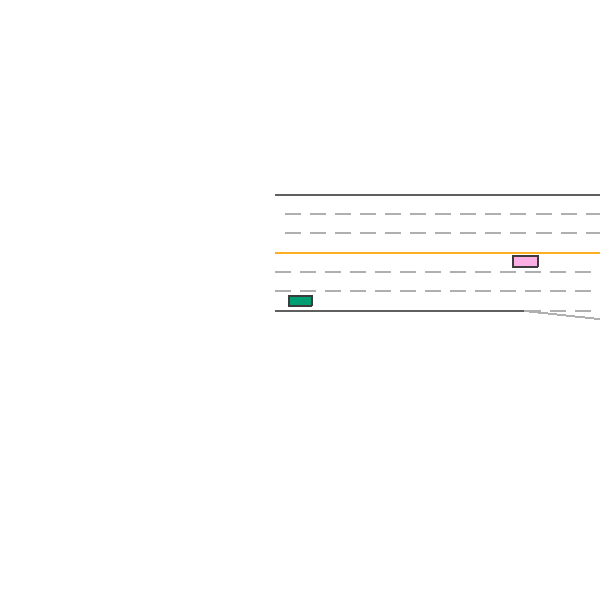

In [5]:
# Генерация GIF с визуализацией траектории
if hasattr(base_env, "top_down_renderer") and base_env.top_down_renderer is not None:
    gif_path = "trajectory_with_crossings.gif"
    try:
        base_env.top_down_renderer.generate_gif(gif_name=gif_path)
        print(f"✅ GIF создан: {gif_path}")
        print(f"   Траектория: {len(detector.get_trajectory())} точек")
        print(f"   Пересечений: {len(all_intersections)}")
        
        # Показываем GIF
        from IPython.display import Image, display
        display(Image(gif_path))
    except Exception as e:
        print(f"❌ Ошибка при создании GIF: {e}")
else:
    print("❌ Рендерер недоступен для создания GIF")


In [6]:
# Закрытие окружения
env.close()
print("✅ Окружение закрыто")


✅ Окружение закрыто
